# RNN Day 1 Housing Data

### Importing Libraries

In [1]:
import os
from pathlib import Path

import pandas as pd                                 # table/dataframe handling
import numpy as np                                  # numerical operations
import matplotlib.pyplot as plt                     # plotting

from sklearn.preprocessing import MinMaxScaler      # scales values to 0-1 range
from sklearn.metrics import mean_absolute_error, mean_squared_error 
                                                    # RMSE and MAE calculation

import tensorflow as tf
import random

from tensorflow.keras.models import Sequential      # sequential neural network API

from tensorflow.keras.layers import (
    Dense,                                          # standard fully connected layer
    SimpleRNN,                                      # recurrent neural network layer
    Conv1D,                                         # 1D convolution layer
    Flatten,                                        # flatten multidimensional output
    Dropout,                                        # regularization for experiments
)

# Run from Week 9 so ma_lga_12345.csv resolves
for candidate in [Path.cwd(), Path.cwd() / "Week 9"]:
    if (candidate / "ma_lga_12345.csv").is_file():
        os.chdir(candidate)
        break
else:
    week9 = Path("/Users/mkenne16/Documents/Advanced Machine Learning/Week 9")
    if (week9 / "ma_lga_12345.csv").is_file():
        os.chdir(week9)

DATA_FILE = Path("ma_lga_12345.csv")
assert DATA_FILE.is_file(), f"Missing {DATA_FILE}. Place ma_lga_12345.csv in Week 9."
print("Working directory:", Path.cwd())

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

Working directory: /Users/mkenne16/Documents/Advanced Machine Learning/Week 9


### Loading the data

In [2]:
house = pd.read_csv(DATA_FILE)              # load housing dataset

house.head()                              # inspect first few rows

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


### Inspecting the temporal nature of the data

In [3]:
print(house.shape)            # number of rows and columns
print(house.dtypes)           # variable data types
print(house.isna().sum())     # missing values per column

house.describe()              # summary statistics

(347, 4)
saledate      str
MA          int64
type          str
bedrooms    int64
dtype: object
saledate    0
MA          0
type        0
bedrooms    0
dtype: int64


,MA,bedrooms
count,3.470000e+02,347.000000
mean,5.481320e+05,2.867435
std,1.701934e+05,1.239875
min,3.167510e+05,1.000000
25%,4.277395e+05,2.000000
50%,5.077440e+05,3.000000
75%,6.275155e+05,4.000000
max,1.017752e+06,5.000000


## Defining useful functions


Formatting data for rolling windows

In [4]:
def create_sequences(dataset, look_back=2):

    X, y = [], []                          # containers for windows and targets

    for i in range(len(dataset) - look_back):

        X.append(dataset[i:i + look_back, :])   # rolling window
        y.append(dataset[i + look_back, 0])     # next timestep target

    return np.array(X), np.array(y)

Plotting training curves

In [5]:
def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].set_ylim(0, 0.4)
    axes[0].legend()

    axes[1].plot(history.history["mean_absolute_error"], label="Training MAE")
    axes[1].plot(history.history["val_mean_absolute_error"], label="Validation MAE")
    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")
    axes[1].set_ylim(0, 0.65)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Evaluating model performance on test data

In [6]:
def evaluate_and_plot(model, trainX, testX, trainY, testY, scaler, title):

    # Make predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Convert scaled values back to original MA scale
    train_pred_inv = scaler.inverse_transform(train_pred)
    test_pred_inv = scaler.inverse_transform(test_pred)
    trainY_inv = scaler.inverse_transform(trainY.reshape(-1, 1))
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    # Calculate RMSE on original scale
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    # Plot held-out future test predictions
    plt.figure(figsize=(10, 4))
    plt.plot(testY_inv, label="Actual")
    plt.plot(test_pred_inv, label="Predicted")

    plt.title(title + " Test Predictions")
    plt.xlabel("Test time index")
    plt.ylabel("MA")
    plt.ylim(0, 1200000)
    plt.ticklabel_format(style="plain", axis="y")
    plt.legend()
    plt.show()

Comparing forcasting performance metrics

In [7]:

def evaluate_metrics(model, testX, testY, scaler):

    test_pred = model.predict(testX)

    test_pred_inv = scaler.inverse_transform(test_pred)
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Initial RNN & Performance

In [8]:
# Initial RNN

ma_sequence = house.copy()
ma_sequence = ma_sequence.sort_values("saledate").reset_index(drop=True)
                                                                # preserve chronological order

df_initial = ma_sequence[["MA"]].copy()                         # univariate forecasting feature

scaler_initial = MinMaxScaler(feature_range=(0, 1))
scaled_initial = scaler_initial.fit_transform(df_initial)
                                                                # neural networks train better on scaled values

look_back = 2                                                   # use previous 2 timesteps to predict next timestep

train_size = int(len(scaled_initial) * 0.8)

train_initial = scaled_initial[:train_size]                     # earlier historical data
test_initial = scaled_initial[train_size:]                      # held-out future data

trainX_initial, trainY_initial = create_sequences(
    train_initial,
    look_back
)                                                               # rolling training windows

testX_initial, testY_initial = create_sequences(
    test_initial,
    look_back
)                                                               # rolling future test windows

print("trainX shape:", trainX_initial.shape)
print("testX shape:", testX_initial.shape)

initial_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_initial.shape[2])
    ),                                                          # recurrent hidden layer

    Dense(1)                                                    # regression output layer
])

initial_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

initial_history = initial_model.fit(
    trainX_initial,
    trainY_initial,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                                              # preserve temporal order
    verbose=1
)

trainX shape: (275, 2, 1)
testX shape: (68, 2, 1)
Epoch 1/100


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0837 - mean_absolute_error: 0.2303 - val_loss: 0.0884 - val_mean_absolute_error: 0.2418
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0671 - mean_absolute_error: 0.2065 - val_loss: 0.0744 - val_mean_absolute_error: 0.2194
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0588 - mean_absolute_error: 0.1904 - val_loss: 0.0669 - val_mean_absolute_error: 0.2029
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0547 - mean_absolute_error: 0.1817 - val_loss: 0.0631 - val_mean_absolute_error: 0.1940
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0528 - mean_absolute_error: 0.1778 - val_loss: 0.0613 - val_mean_absolute_error: 0.1888
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0518 - mean_absolute_error: 0.1758 - val_loss: 0.0604 - val_mean_absolute_error: 0.1859
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0513 - mean_absolute_error: 0.1746 - val_loss: 0.0600 - 

Training curves

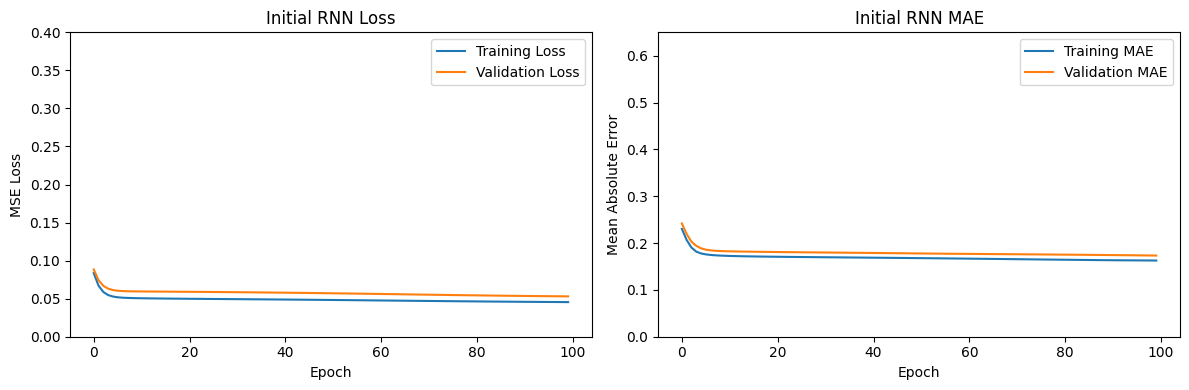

In [9]:
plot_training_curves(
    initial_history,
    "Initial RNN"
)

Test data evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Initial RNN Train RMSE: 150505.92
Initial RNN Test RMSE: 150254.06


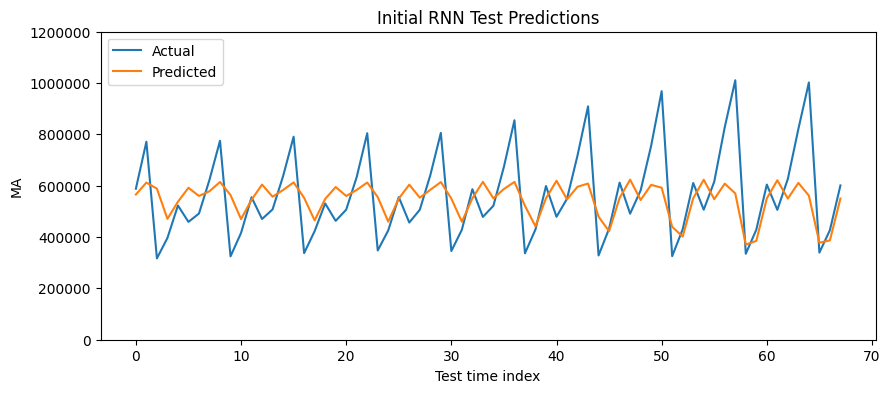

In [10]:
evaluate_and_plot(
    initial_model,
    trainX_initial,
    testX_initial,
    trainY_initial,
    testY_initial,
    scaler_initial,
    "Initial RNN"
)

### Initial MA data re-evaluation

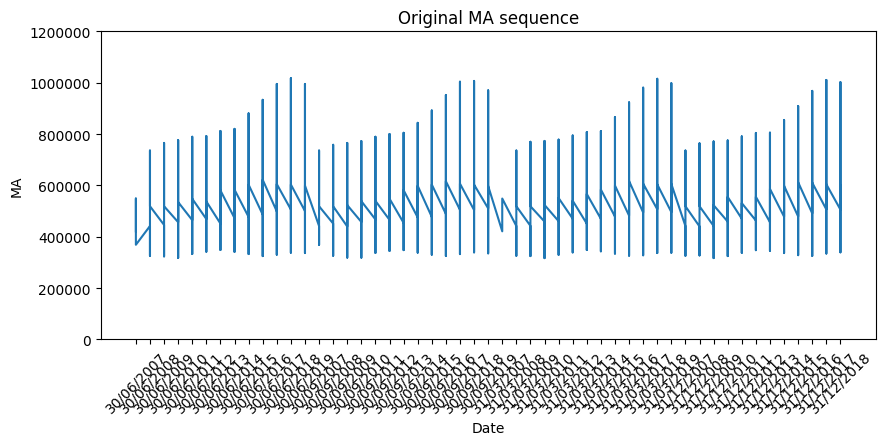

In [11]:
# Plot the original MA sequence exactly as provided

plt.figure(figsize=(10, 4))

plt.plot(
    ma_sequence["saledate"],
    ma_sequence["MA"]
)

plt.title("Original MA sequence")
plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)                                        

plt.xticks(rotation=45)

plt.show()


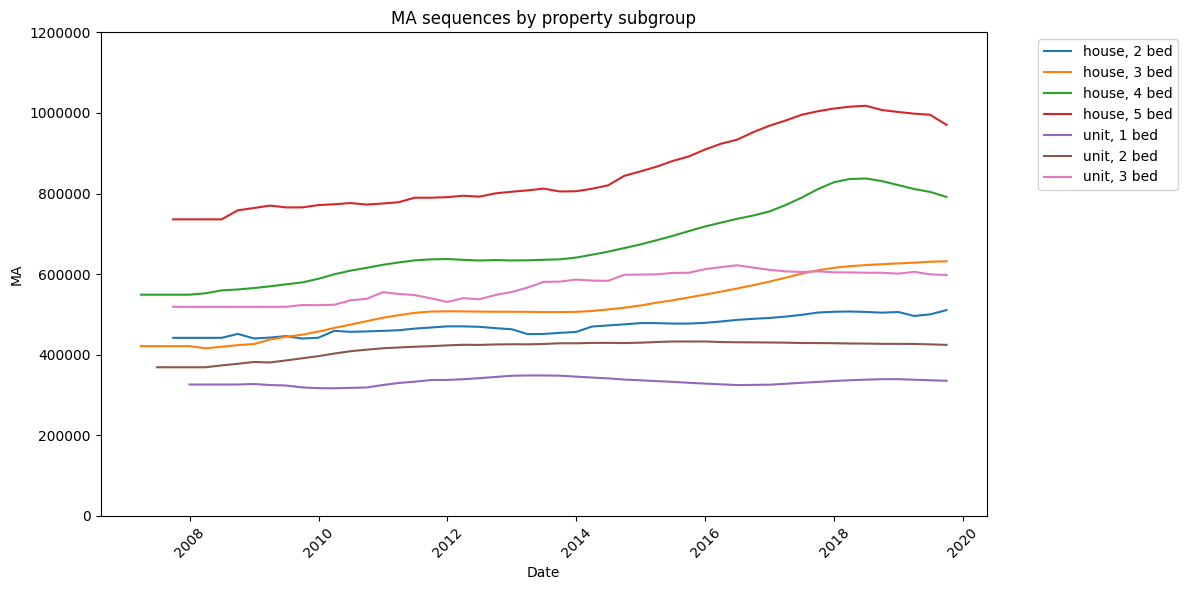

In [12]:
# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

plt.figure(figsize=(12, 6))

for (property_type, bedrooms), group in house.groupby(["type", "bedrooms"]):

    group = group.sort_values("saledate")      # chronological ordering

    plt.plot(
        group["saledate"],
        group["MA"],
        label=f"{property_type}, {bedrooms} bed"
    )

plt.title("MA sequences by property subgroup")

plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

Inspecting the first window

In [13]:
print("trainX_initial shape:", trainX_initial.shape)

window_id = 0

ma_sequence.iloc[
    window_id : window_id + look_back + 1
][["saledate", "type", "bedrooms", "MA"]]

trainX_initial shape: (275, 2, 1)


,saledate,type,bedrooms,MA
0,30/06/2007,house,3,421291
1,30/06/2007,house,4,548969
2,30/06/2007,unit,2,368817


### Creating market-level MA data

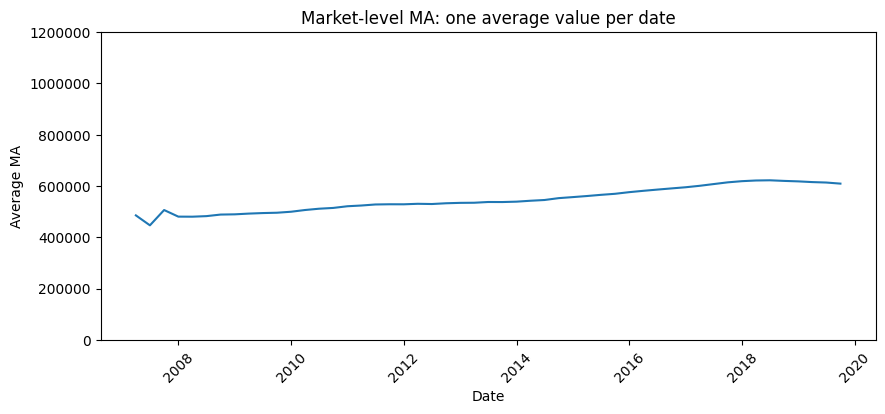

In [14]:
# Create market-level MA sequence

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)                                                    # ensure dates sort chronologically

market_ma = (
    house
    .groupby("saledate")["MA"]
    .mean()
    .reset_index()
    .sort_values("saledate")
    .reset_index(drop=True)
)                                                    # average subgroup MAs per date

# Visualize market-level MA

plt.figure(figsize=(10, 4))

plt.plot(
    market_ma["saledate"],
    market_ma["MA"]
)

plt.title("Market-level MA: one average value per date")
plt.xlabel("Date")
plt.ylabel("Average MA")

plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)

plt.show()

### Preparing market-level MA data for variety of models

In [15]:
# Prepare market-level MA data for all fixed-data models

df_market = market_ma[["MA"]].copy()                            # cleaned one-value-per-date MA series

scaler_market = MinMaxScaler(feature_range=(0, 1))              # scale MA values for neural networks
scaled_market = scaler_market.fit_transform(df_market)

look_back = 2                                                   # use 2 previous timesteps to predict next timestep

train_size = int(len(scaled_market) * 0.8)                      # chronological 80/20 split

train_market = scaled_market[:train_size]                       # earlier historical data
test_market = scaled_market[train_size:]                        # held-out future data

trainX_market, trainY_market = create_sequences(
    train_market,
    look_back
)                                                               # sequence windows for RNN/CNN

testX_market, testY_market = create_sequences(
    test_market,
    look_back
)                                                               # future test windows for RNN/CNN

trainX_market_mlp = trainX_market.reshape(
    trainX_market.shape[0],
    trainX_market.shape[1] * trainX_market.shape[2]
)                                                               # flattened windows for MLP

testX_market_mlp = testX_market.reshape(
    testX_market.shape[0],
    testX_market.shape[1] * testX_market.shape[2]
)                                                               # flattened test windows for MLP

print("RNN/CNN trainX_market shape:", trainX_market.shape)
print("RNN/CNN testX_market shape:", testX_market.shape)

print("MLP trainX_market_mlp shape:", trainX_market_mlp.shape)
print("MLP testX_market_mlp shape:", testX_market_mlp.shape)

RNN/CNN trainX_market shape: (38, 2, 1)
RNN/CNN testX_market shape: (9, 2, 1)
MLP trainX_market_mlp shape: (38, 2)
MLP testX_market_mlp shape: (9, 2)


### Inspecting the tensors

Shape & window 0 values

In [16]:
print("trainX_market shape:", trainX_market.shape)

window_id = 0

market_ma.iloc[
    window_id : window_id + look_back + 1
][["saledate", "MA"]]

trainX_market shape: (38, 2, 1)


,saledate,MA
0,2007-03-31,485130.000000
1,2007-06-30,446359.000000
2,2007-09-30,505957.666667


Scale window 0

In [17]:
# Visualize one input window and its target

window_id = 0

print("Input window:")
print(trainX_market[window_id].flatten())

print("Target:")
print(trainY_market[window_id])

Input window:
[0.22095731 0.        ]
Target:
0.33965492068299463


### Market-level RNN model & evaluation

In [18]:
# Build and train market-level RNN model

market_rnn_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_market.shape[2])
    ),
    Dense(1)
])

market_rnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_rnn_history = market_rnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0500 - mean_absolute_error: 0.2169 - val_loss: 0.1204 - val_mean_absolute_error: 0.3453
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0223 - mean_absolute_error: 0.1427 - val_loss: 0.0597 - val_mean_absolute_error: 0.2425
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0068 - mean_absolute_error: 0.0768 - val_loss: 0.0229 - val_mean_absolute_error: 0.1492
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0017 - mean_absolute_error: 0.0272 - val_loss: 0.0061 - val_mean_absolute_error: 0.0754
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0028 - mean_absolute_error: 0.0423 - val_loss: 0.0013 - val_mean_absolute_error: 0.0306
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0049 - mean_absolute_error: 0.0608 - val_loss: 6.6128e-04 - val_mean_absolute_error: 0.0215
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0052 - mean_absolute_error: 0.0612 - val_loss: 0.0013 - val_

Training curves

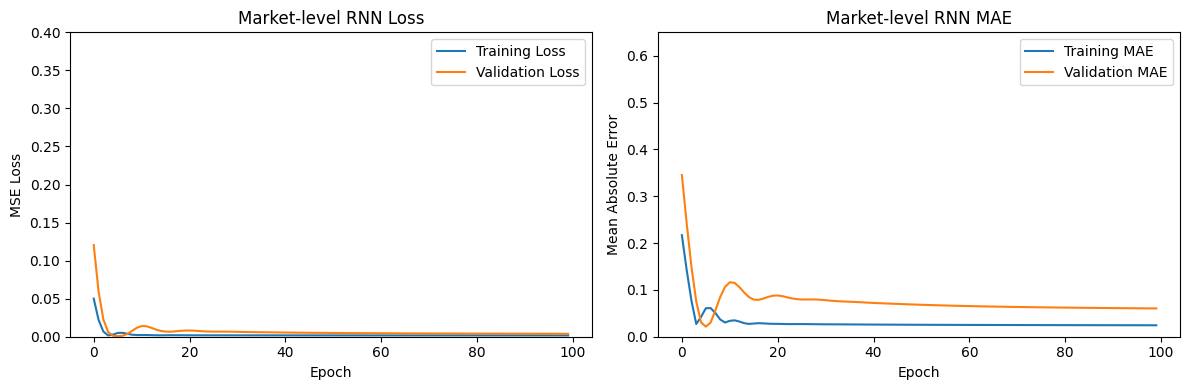

In [19]:
plot_training_curves(
    market_rnn_history,
    "Market-level RNN"
)

Test data evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Market-level RNN Train RMSE: 8131.16
Market-level RNN Test RMSE: 15985.01


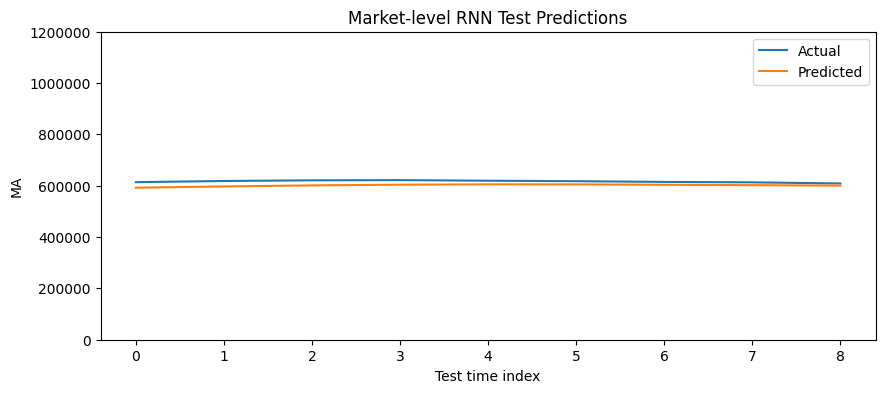

In [20]:
evaluate_and_plot(
    market_rnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level RNN"
)

### Market level MLP and evaluation

In [21]:
# Build and train market-level MLP model

market_mlp_model = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(trainX_market_mlp.shape[1],)
    ),
    Dense(
        16,
        activation="relu"
    ),
    Dense(1)
])

market_mlp_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_mlp_history = market_mlp_model.fit(
    trainX_market_mlp,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0963 - mean_absolute_error: 0.2989 - val_loss: 0.2720 - val_mean_absolute_error: 0.5195
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0762 - mean_absolute_error: 0.2646 - val_loss: 0.2254 - val_mean_absolute_error: 0.4728
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0604 - mean_absolute_error: 0.2341 - val_loss: 0.1870 - val_mean_absolute_error: 0.4305
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0456 - mean_absolute_error: 0.2016 - val_loss: 0.1498 - val_mean_absolute_error: 0.3851
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0322 - mean_absolute_error: 0.1670 - val_loss: 0.1146 - val_mean_absolute_error: 0.3366
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0213 - mean_absolute_error: 0.1330 - val_loss: 0.0845 - val_mean_absolute_error: 0.2888
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0130 - mean_absolute_error: 0.1011 - val_loss: 0.0601 - val_mean

Training curves MLP

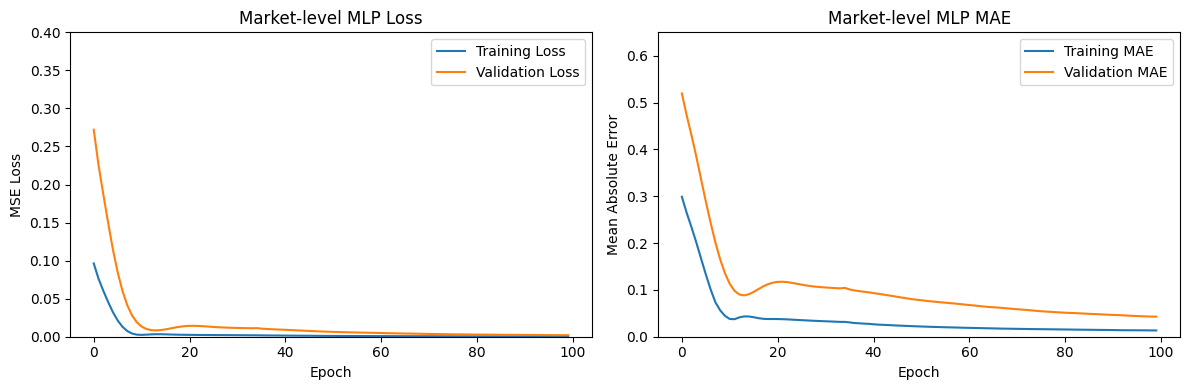

In [22]:
plot_training_curves(
    market_mlp_history,
    "Market-level MLP"
)

Test data evaluation MLP

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/stepWARNING:tensorflow:6 out of the last 17 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x3111ce7a0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Market-level MLP Train RMSE: 4631.41
Market-level MLP Test RMSE: 10526.73


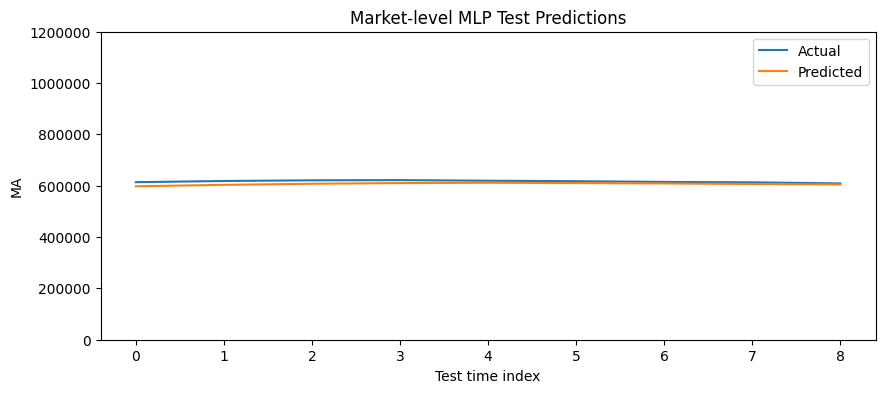

In [23]:
evaluate_and_plot(
    market_mlp_model,
    trainX_market_mlp,
    testX_market_mlp,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level MLP"
)

### Market level CNN & evaluation

In [24]:
# Build and train market-level 1D CNN model

market_cnn_model = Sequential([
    Conv1D(
        filters=16,                         # learn 16 temporal pattern detectors
        kernel_size=2,                      # each filter looks across 2 neighboring timesteps
        activation="relu",
        input_shape=(look_back, trainX_market.shape[2])
    ),                                      # input shape = timesteps, features

    Flatten(),                              # convert CNN output to flat vector for Dense layer

    Dense(1)                                # regression output layer
])

market_cnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_cnn_history = market_cnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                          # preserve temporal order
    verbose=1
)

Epoch 1/100


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0999 - mean_absolute_error: 0.3029 - val_loss: 0.2975 - val_mean_absolute_error: 0.5433
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0884 - mean_absolute_error: 0.2840 - val_loss: 0.2710 - val_mean_absolute_error: 0.5184
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0778 - mean_absolute_error: 0.2656 - val_loss: 0.2458 - val_mean_absolute_error: 0.4937
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0681 - mean_absolute_error: 0.2474 - val_loss: 0.2222 - val_mean_absolute_error: 0.4693
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0592 - mean_absolute_error: 0.2297 - val_loss: 0.2003 - val_mean_absolute_error: 0.4455
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0514 - mean_absolute_error: 0.2127 - val_loss: 0.1801 - val_mean_absolute_error: 0.4224
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0445 - mean_absolute_error: 0.1967 - val_loss: 0.1618 - val_mean

Training curves 1D CNN

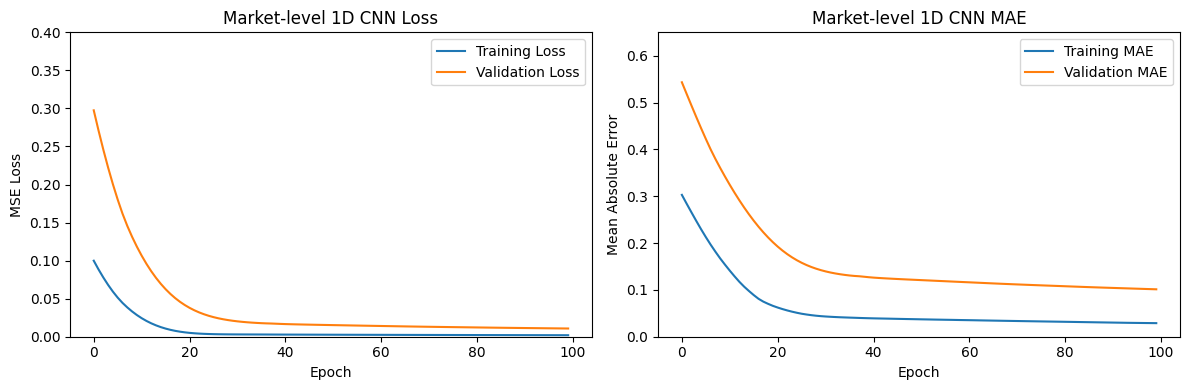

In [25]:
plot_training_curves(
    market_cnn_history,
    "Market-level 1D CNN"
)

Test data evaluation 1D CNN

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Market-level 1D CNN Train RMSE: 10858.94
Market-level 1D CNN Test RMSE: 27010.29


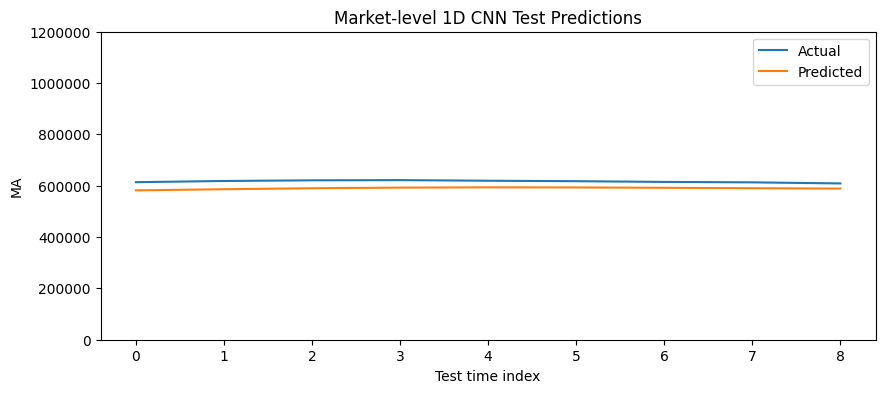

In [26]:
evaluate_and_plot(
    market_cnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level 1D CNN"
)

### Comparison of RNN vs MLP vs 1D CNN

In [27]:
rnn_rmse, rnn_mae = evaluate_metrics(
    market_rnn_model,
    testX_market,
    testY_market,
    scaler_market
)

mlp_rmse, mlp_mae = evaluate_metrics(
    market_mlp_model,
    testX_market_mlp,
    testY_market,
    scaler_market
)

cnn_rmse, cnn_mae = evaluate_metrics(
    market_cnn_model,
    testX_market,
    testY_market,
    scaler_market
)

comparison = pd.DataFrame({
    "Model": ["RNN", "MLP", "1D CNN"],
    "RMSE": [rnn_rmse, mlp_rmse, cnn_rmse],
    "MAE": [rnn_mae, mlp_mae, cnn_mae]
})

comparison

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


,Model,RMSE,MAE
0,RNN,15985.008451,15295.126984
1,MLP,10526.726267,9675.571429
2,1D CNN,27010.288619,26676.696429


### Your Turn — Build and Compare RNN Models

Choose one or more coherent housing subgroups (for example, 3-bedroom houses) and build at least 3 meaningfully different RNN forecasting models. Evaluate each model using training/validation curves, held-out future test predictions, RMSE, and MAE, and record your observations in markdown cells throughout the notebook.

### Model Exploration Summary

Briefly summarize which subgroup(s) and model variations you explored, what changes appeared to improve or worsen forecasting performance, any patterns you noticed in the training curves or predictions, and which model you believe performed best and why.


- **Subgroup explored:** 3-bedroom houses (`type == "house"`, `bedrooms == 3`)
- **Model variations:** (1) look_back=2, 16 units — (2) look_back=4, 32 units — (3) look_back=2, 32 units + dropout 0.2
- **What improved performance:** *(compare RMSE/MAE table and prediction plots)*
- **Tradeoffs:** *(e.g. longer lookback needs more data; dropout slowed overfitting but …)*
- **Best model:** *(name + why — lowest test RMSE/MAE with stable val curves)*



In [28]:
# Subgroup: 3-bedroom houses (one coherent quarterly MA series)
subgroup = (
    house[(house["type"] == "house") & (house["bedrooms"] == 3)]
    .sort_values("saledate")
    .reset_index(drop=True)
)
print(f"Subgroup: 3-bedroom houses | rows: {len(subgroup)}")


def fit_subgroup_rnn(name, look_back, rnn_units, dropout_rate=0.0, epochs=100):
    """Train a SimpleRNN forecaster on the subgroup; return metrics and artifacts."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    df = subgroup[["MA"]].copy()
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(df)

    train_size = int(len(scaled) * 0.8)
    train_s, test_s = scaled[:train_size], scaled[train_size:]

    trainX, trainY = create_sequences(train_s, look_back)
    testX, testY = create_sequences(test_s, look_back)

    layers_list = [
        SimpleRNN(rnn_units, activation="tanh", input_shape=(look_back, 1)),
    ]
    if dropout_rate:
        layers_list.append(Dropout(dropout_rate))
    layers_list.append(Dense(1))

    model = Sequential(layers_list)
    model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mean_absolute_error"])

    history = model.fit(
        trainX, trainY,
        epochs=epochs,
        batch_size=8,
        validation_split=0.2,
        shuffle=False,
        verbose=0,
    )

    rmse, mae = evaluate_metrics(model, testX, testY, scaler)
    print(f"{name}: test RMSE={rmse:,.0f}  MAE={mae:,.0f}")

    return {
        "name": name,
        "look_back": look_back,
        "units": rnn_units,
        "dropout": dropout_rate,
        "history": history,
        "model": model,
        "rmse": rmse,
        "mae": mae,
        "trainX": trainX,
        "testX": testX,
        "trainY": trainY,
        "testY": testY,
        "scaler": scaler,
    }


# Three meaningfully different RNN configs
exp_results = []
exp_results.append(fit_subgroup_rnn("RNN_lb2_u16", look_back=2, rnn_units=16))
exp_results.append(fit_subgroup_rnn("RNN_lb4_u32", look_back=4, rnn_units=32))
exp_results.append(fit_subgroup_rnn("RNN_lb2_u32_drop", look_back=2, rnn_units=32, dropout_rate=0.2))



Subgroup: 3-bedroom houses | rows: 51


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
RNN_lb2_u16: test RMSE=24,013  MAE=23,999


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
RNN_lb4_u32: test RMSE=51,150  MAE=51,118


/Users/mkenne16/Documents/Advanced Machine Learning/week 7/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
RNN_lb2_u32_drop: test RMSE=5,425  MAE=3,776


In [29]:
# Compare experiment models (RMSE / MAE on held-out test)
exp_comparison = pd.DataFrame([
    {
        "Model": r["name"],
        "look_back": r["look_back"],
        "units": r["units"],
        "dropout": r["dropout"],
        "test_RMSE": round(r["rmse"], 2),
        "test_MAE": round(r["mae"], 2),
    }
    for r in exp_results
])
exp_comparison



,Model,look_back,units,dropout,test_RMSE,test_MAE
0,RNN_lb2_u16,2,16,0.0,24012.80,23999.35
1,RNN_lb4_u32,4,32,0.0,51149.69,51118.46
2,RNN_lb2_u32_drop,2,32,0.2,5425.01,3775.84


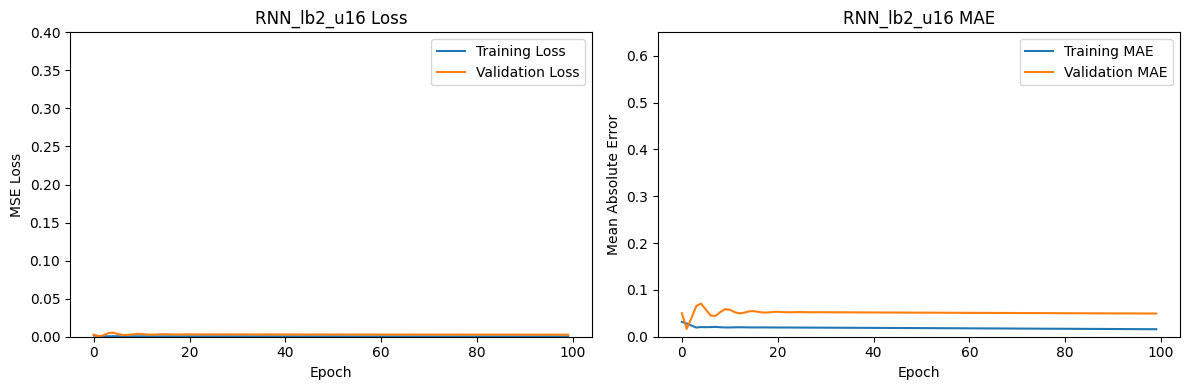

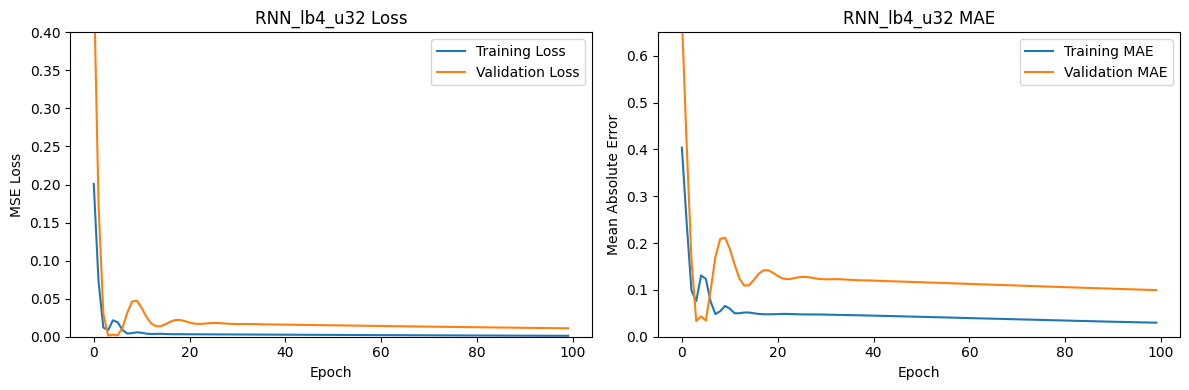

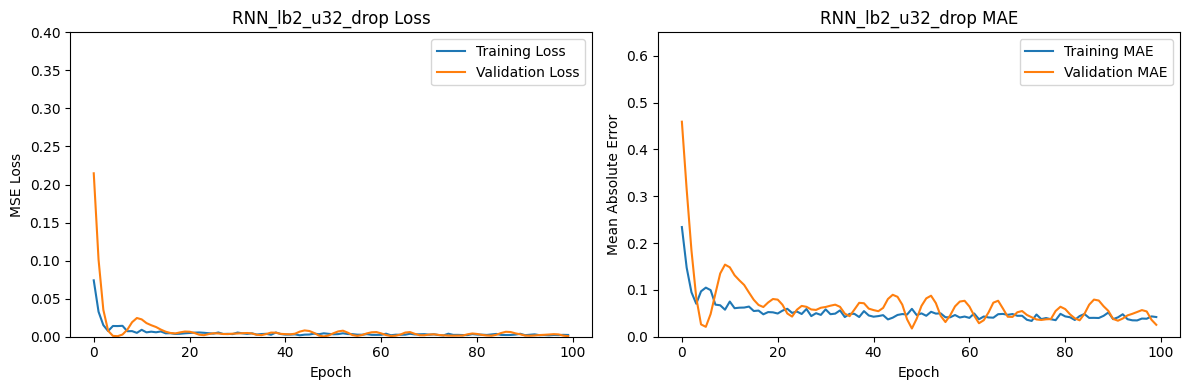

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
RNN_lb2_u16 Train RMSE: 6229.28
RNN_lb2_u16 Test RMSE: 24012.80


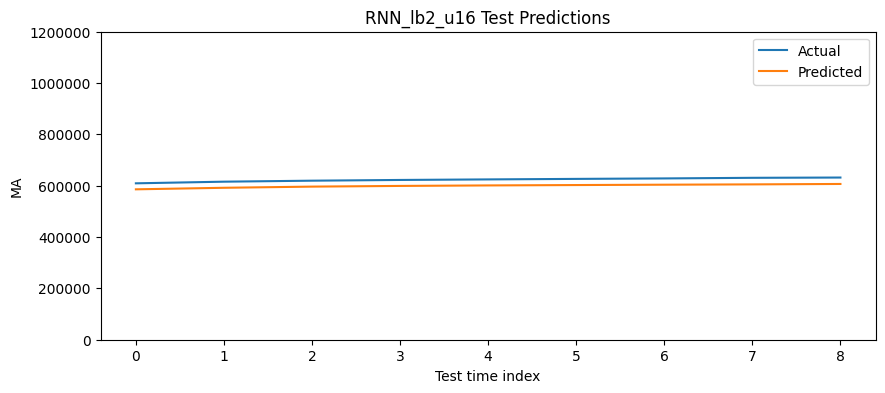

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
RNN_lb4_u32 Train RMSE: 12519.16
RNN_lb4_u32 Test RMSE: 51149.69


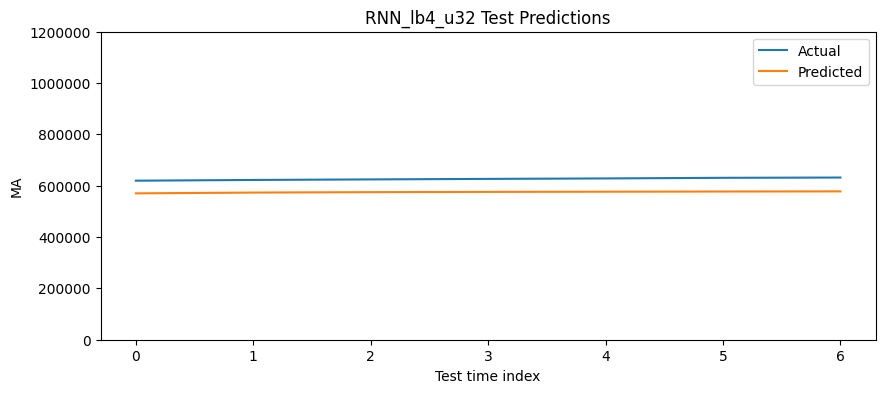

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
RNN_lb2_u32_drop Train RMSE: 7102.32
RNN_lb2_u32_drop Test RMSE: 5425.01


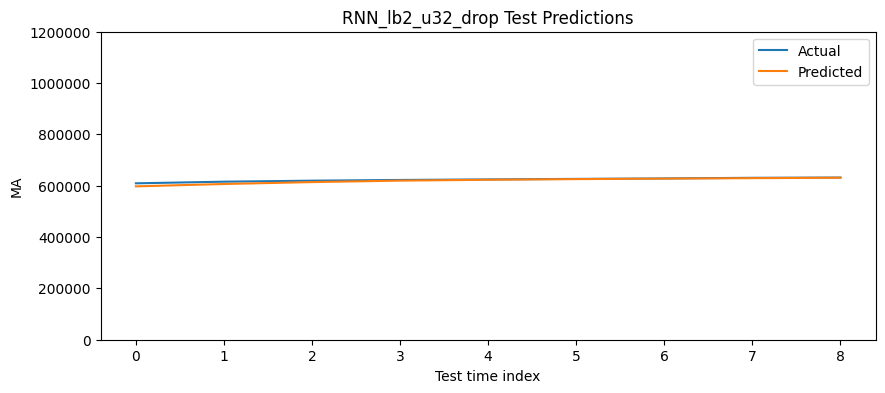

In [30]:
# Training curves for each experiment model
for r in exp_results:
    plot_training_curves(r["history"], r["name"])

# Held-out test prediction plots
for r in exp_results:
    evaluate_and_plot(
        r["model"],
        r["trainX"],
        r["testX"],
        r["trainY"],
        r["testY"],
        r["scaler"],
        r["name"],
    )

